# Diabetes Risk Prediction using Machine Learning

## Objective
To build and compare machine learning models for predicting diabetes risk.

Models Used:
- Support Vector Machine (SVM)
- XGBoost

Key Focus:
- Improve Recall (reduce false negatives)
- Optimize using Optuna
- Compare final performance

This is a medical screening task, so recall is important.

In [6]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.svm import SVC

import optuna
from xgboost import XGBClassifier

In [7]:
# 3️ Load Dataset
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


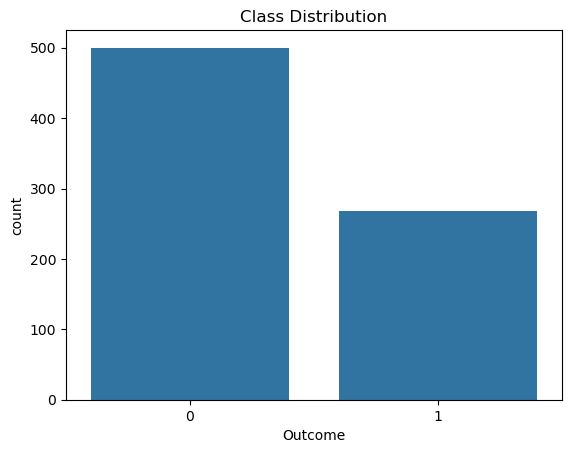

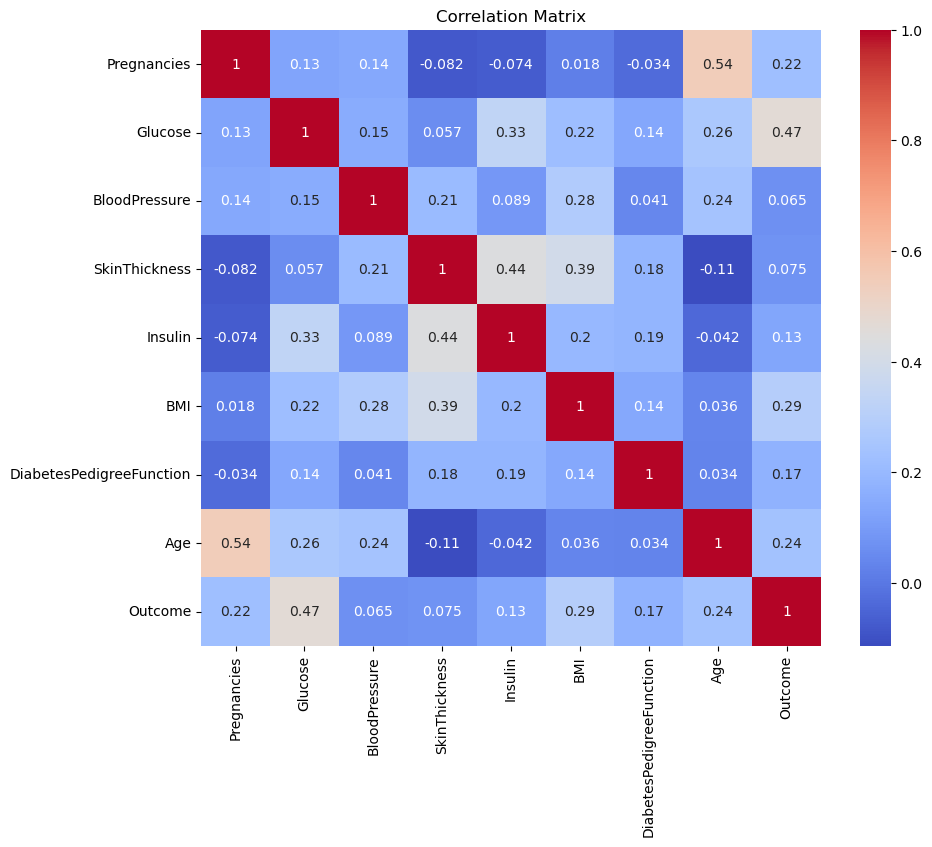

In [8]:
# 4. EDA
sns.countplot(x="Outcome", data=df)
plt.title("Class Distribution")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [9]:
# 5.Daya set spliting

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

# SVM MODEL

In [10]:
# SVM Hyperparameter Tuning (Optuna)

def svm_objective(trial):
    
    C = trial.suggest_float("C", 0.01, 100, log=True)
    gamma = trial.suggest_float("gamma", 1e-4, 1, log=True)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(
            C=C,
            gamma=gamma,
            kernel="rbf",
            class_weight="balanced",
            probability=True
        ))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    ).mean()

    return score


svm_study = optuna.create_study(direction="maximize")
svm_study.optimize(svm_objective, n_trials=50)

svm_best_params = svm_study.best_params
print("Best SVM Params:", svm_best_params)

[I 2026-03-01 13:57:57,883] A new study created in memory with name: no-name-a1c3bc8e-b2f0-4136-a190-55b3de815d68
[I 2026-03-01 13:57:58,482] Trial 0 finished with value: 0.6463437264851316 and parameters: {'C': 13.118660867884987, 'gamma': 0.00014147346430096747}. Best is trial 0 with value: 0.6463437264851316.
[I 2026-03-01 13:57:58,794] Trial 1 finished with value: 0.6621880757566473 and parameters: {'C': 0.24971117027001324, 'gamma': 0.033068680905325096}. Best is trial 1 with value: 0.6621880757566473.
[I 2026-03-01 13:57:59,195] Trial 2 finished with value: 0.617174987526786 and parameters: {'C': 0.06452743199908303, 'gamma': 0.2709649887499286}. Best is trial 1 with value: 0.6621880757566473.
[I 2026-03-01 13:57:59,548] Trial 3 finished with value: 0.6263861397235468 and parameters: {'C': 80.39260075714203, 'gamma': 0.0070989515629106235}. Best is trial 1 with value: 0.6621880757566473.
[I 2026-03-01 13:57:59,990] Trial 4 finished with value: 0.5433429794842838 and parameters: {

Best SVM Params: {'C': 96.75649448772428, 'gamma': 0.0014245875769195047}


In [11]:
# Train Final SVM

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        C=svm_best_params["C"],
        gamma=svm_best_params["gamma"],
        kernel="rbf",
        class_weight="balanced",
        probability=True
    ))
])

svm_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,96.75649448772428
,kernel,'rbf'
,degree,3
,gamma,0.0014245875769195047


In [12]:
# Threshold Tuning (SVM)

y_prob_val = svm_model.predict_proba(X_val)[:, 1]

best_threshold_svm = 0
best_f1_svm = 0

for t in np.arange(0.1, 0.9, 0.01):
    y_pred_val = (y_prob_val >= t).astype(int)
    f1 = f1_score(y_val, y_pred_val)

    if f1 > best_f1_svm:
        best_f1_svm = f1
        best_threshold_svm = t

print("Best SVM Threshold:", best_threshold_svm)

Best SVM Threshold: 0.4299999999999998


In [13]:
# Final SVM Evaluation

y_prob_test_svm = svm_model.predict_proba(X_test)[:, 1]
y_test_pred_svm = (y_prob_test_svm >= best_threshold_svm).astype(int)

print("SVM Results")
print(classification_report(y_test, y_test_pred_svm))

svm_auc = roc_auc_score(y_test, y_prob_test_svm)
print("SVM ROC-AUC:", svm_auc)

SVM Results
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       100
           1       0.60      0.56      0.58        54

    accuracy                           0.71       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154

SVM ROC-AUC: 0.8283333333333334


# XGBOOST MODEL

In [14]:
# XGBoost Hyperparameter Tuning
def xgb_objective(trial):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": len(y_train[y_train==0]) / len(y_train[y_train==1]),
        "eval_metric": "logloss",
        "use_label_encoder": False
    }

    model = XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    ).mean()

    return score


xgb_study = optuna.create_study(direction="maximize")
xgb_study.optimize(xgb_objective, n_trials=50)

xgb_best_params = xgb_study.best_params
print("Best XGB Params:", xgb_best_params)

[I 2026-03-01 14:00:09,891] A new study created in memory with name: no-name-847b29e0-9895-4f10-95ca-131d04daf39c
c:\Users\Admin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:00:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Admin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:00:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Admin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:00:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Admin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:00:11] WARNING: C:\actions-run

Best XGB Params: {'n_estimators': 122, 'max_depth': 3, 'learning_rate': 0.02693308418413369, 'subsample': 0.7147326446967142, 'colsample_bytree': 0.6532242915580753}


In [15]:
# XGBoost Hyperparameter Tuning
xgb_model = XGBClassifier(
    **xgb_best_params,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric="logloss",
    use_label_encoder=False
)


xgb_model.fit(X_train, y_train)

c:\Users\Admin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:01:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6532242915580753
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [16]:
# XGBoost Threshold Tuning
y_prob_val_xgb = xgb_model.predict_proba(X_val)[:, 1]

best_threshold_xgb = 0
best_f1_xgb = 0

for t in np.arange(0.1, 0.9, 0.01):
    y_pred_val = (y_prob_val_xgb >= t).astype(int)
    f1 = f1_score(y_val, y_pred_val)

    if f1 > best_f1_xgb:
        best_f1_xgb = f1
        best_threshold_xgb = t

print("Best XGB Threshold:", best_threshold_xgb)

Best XGB Threshold: 0.43999999999999984


In [18]:
y_prob_test_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_test_pred_xgb = (y_prob_test_xgb >= best_threshold_xgb).astype(int)

print("XGBoost Results")
print(classification_report(y_test, y_test_pred_xgb))

xgb_auc = roc_auc_score(y_test, y_prob_test_xgb)
print("XGBoost ROC-AUC:", xgb_auc)

XGBoost Results
              precision    recall  f1-score   support

           0       0.89      0.74      0.81       100
           1       0.63      0.83      0.72        54

    accuracy                           0.77       154
   macro avg       0.76      0.79      0.76       154
weighted avg       0.80      0.77      0.78       154

XGBoost ROC-AUC: 0.8285185185185185


In [19]:
# Final XGBoost Evaluation
results = pd.DataFrame({
    "Model": ["SVM", "XGBoost"],
    "ROC-AUC": [svm_auc, xgb_auc]
})

results

,Model,ROC-AUC
0,SVM,0.828333
1,XGBoost,0.828519


In [24]:
import joblib

joblib.dump(xgb_model, "diabetes_model.pkl")

['diabetes_model.pkl']